In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py

In [2]:
problem_size = 10**2

In [3]:
def fill_overlap(A):
        A[:2, :] = A[-4:-2, :]
        A[-2:, :] = A[2:4, :]
        A[:, :2] = A[:, -4:-2]
        A[:, -2:] = A[:, 2:4]

        return A

grid_len = int(np.sqrt(problem_size))
ones2d = np.ones((grid_len+4,grid_len+4))

def create(val):
    return ones2d * val

hIceMean  = create(1)
hSnowMean = create(0.1)
Area      = create(0.7)
TSurf     = create(273.0)

uWind  = create(5)
vWind  = create(5)
uOcean = create(0.1)
vOcean = create(0.1)

maskInC = create(1)
maskInC[-3,:] = 0
maskInC[:,-3] = 0
maskInU = maskInC * np.roll(maskInC,5,axis=1)
maskInV = maskInC * np.roll(maskInC,5,axis=0)

maskInC = fill_overlap(maskInC)
maskInU = fill_overlap(maskInU)
maskInV = fill_overlap(maskInV)

R_low  = create(-1000)

fCori = create(1.46e-4)

iceMask, iceMaskU, iceMaskV  = maskInC*1, maskInU*1, maskInV*1

deltaX = create(8000)
dxC, dyC, dxG, dyG, dxU, dyU, dxV, dyV = [deltaX*1 for _ in range(8)]
recip_dxC, recip_dyC, recip_dxG, recip_dyG, recip_dxU, recip_dyU, recip_dxV, recip_dyV = [1 / deltaX for _ in range(8)]

rA  = dxU * dyV
rAz = dxV * dyU
rAu = dxC * dyG
rAv = dxG * dyC
recip_rA = 1 / rA
recip_rAz = 1 / rAz
recip_rAu = 1 / rAu
recip_rAv = 1 / rAv

fields = [
    hIceMean, hSnowMean, Area, TSurf, uOcean, vOcean, uWind, vWind, R_low,
    maskInC, maskInU, maskInV, iceMask, iceMaskU, iceMaskV, fCori,
    dxC, dyC, dxG, dyG, dxU, dyU, dxV, dyV,
    recip_dxC, recip_dyC, recip_dxG, recip_dyG, recip_dxU, recip_dyU, recip_dxV, recip_dyV,
    rA, rAz, rAu, rAv, recip_rA, recip_rAz, recip_rAu, recip_rAv
    ]

def namestr(obj, namespace):
    return [name for name in namespace if namespace[name] is obj][0]

names = [namestr(var, globals()) for var in fields]

init_fields = {name: field for name, field in zip(names, fields)}

with h5py.File('initial_fields.h5', 'w') as file:

    for name, field in zip(names, fields):
        file.create_dataset(name, data=field)

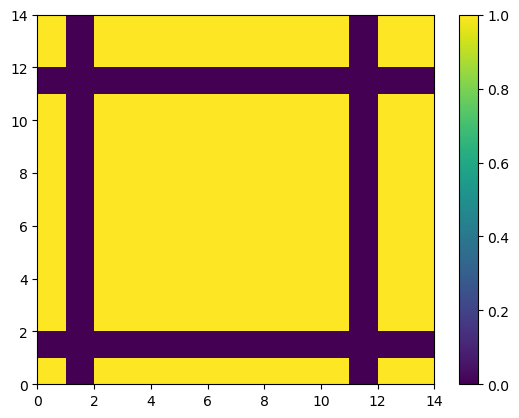

In [4]:
plt.pcolormesh(maskInC)
plt.colorbar()